# Testing ENTSO-E API

Purpose of this notebook is to test fetching different variables fro ENTSO-E. Again, this notebook doesn't have any impact on the project, but was used for us to play around and see what data we can extract from this API. 

It could possibly be used by a successor group to see what kind of data ENTSO-E offers.

Generating the API Key from: https://transparency.entsoe.eu/myAccount/webApiAccess

In [ ]:
TOKEN = "API-KEY" #enter your sectret key

Installing the pip:

(no need to re-run this step)

In [ ]:
pip install entsoe-py
pip install matplotlib

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 2.5 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.0 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 3.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 3.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.9 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 2.8 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 2.7 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing the libraries:

In [ ]:
from entsoe import EntsoePandasClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Setting up the API:

In [6]:
client = EntsoePandasClient(api_key=TOKEN)

Setting up some basic parameters for testing:

In [7]:
#Let's start by testing the data for the month of january 2026
start = pd.Timestamp('20260101', tz='Europe/Brussels')    
end = pd.Timestamp('20260201', tz='Europe/Brussels')
#let's check the data for Germany, and generation flows from Germany to France
country_code = 'DE_LU' 
country_code_from = 'DE_LU' 
country_code_to = 'FR' 
#A01 is the code for "day ahead" values"
type_marketagreement_type = 'A01'
contract_marketagreement_type = "A01"
#I don't know what this means i took it from the manual xD
process_type = 'A51'

### Electricity Price Germany January 2026

In [8]:
e_prices_jan26 = client.query_day_ahead_prices(country_code, start=start, end=end)

In [9]:
type_jan = type(e_prices_jan26)
head_jan = e_prices_jan26.head(5)
info_jan = e_prices_jan26.info()

print(type_jan)
print(head_jan)
print(info_jan)

<class 'pandas.Series'>
DatetimeIndex: 2977 entries, 2026-01-01 00:00:00+01:00 to 2026-02-01 00:00:00+01:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
2977 non-null   float64
dtypes: float64(1)
memory usage: 46.5 KB
<class 'pandas.Series'>
2026-01-01 00:00:00+01:00    63.64
2026-01-01 00:15:00+01:00    61.48
2026-01-01 00:30:00+01:00    58.00
2026-01-01 00:45:00+01:00    49.99
2026-01-01 01:00:00+01:00    60.01
dtype: float64
None


As we can see it is giving us a pandas array for every date we specified for every 15 minutes. In the third column we can see the price.


I will make a plot of the movement of prices for the first day of 2026

In [41]:
start2 = pd.Timestamp('20260101', tz='Europe/Brussels')    
end2 = pd.Timestamp('20260102', tz='Europe/Brussels')

In [11]:
e_price_jan1 = client.query_day_ahead_prices(country_code, start=start2, end=end2)

In [12]:
df = e_price_jan1.to_frame(name="price")
df["date"] = df.index.date                    
df["time"] = df.index.strftime("%H:%M")      
df.head(5)

,price,date,time
2026-01-01 00:00:00+01:00,63.64,2026-01-01,00:00
2026-01-01 00:15:00+01:00,61.48,2026-01-01,00:15
2026-01-01 00:30:00+01:00,58.00,2026-01-01,00:30
2026-01-01 00:45:00+01:00,49.99,2026-01-01,00:45
2026-01-01 01:00:00+01:00,60.01,2026-01-01,01:00


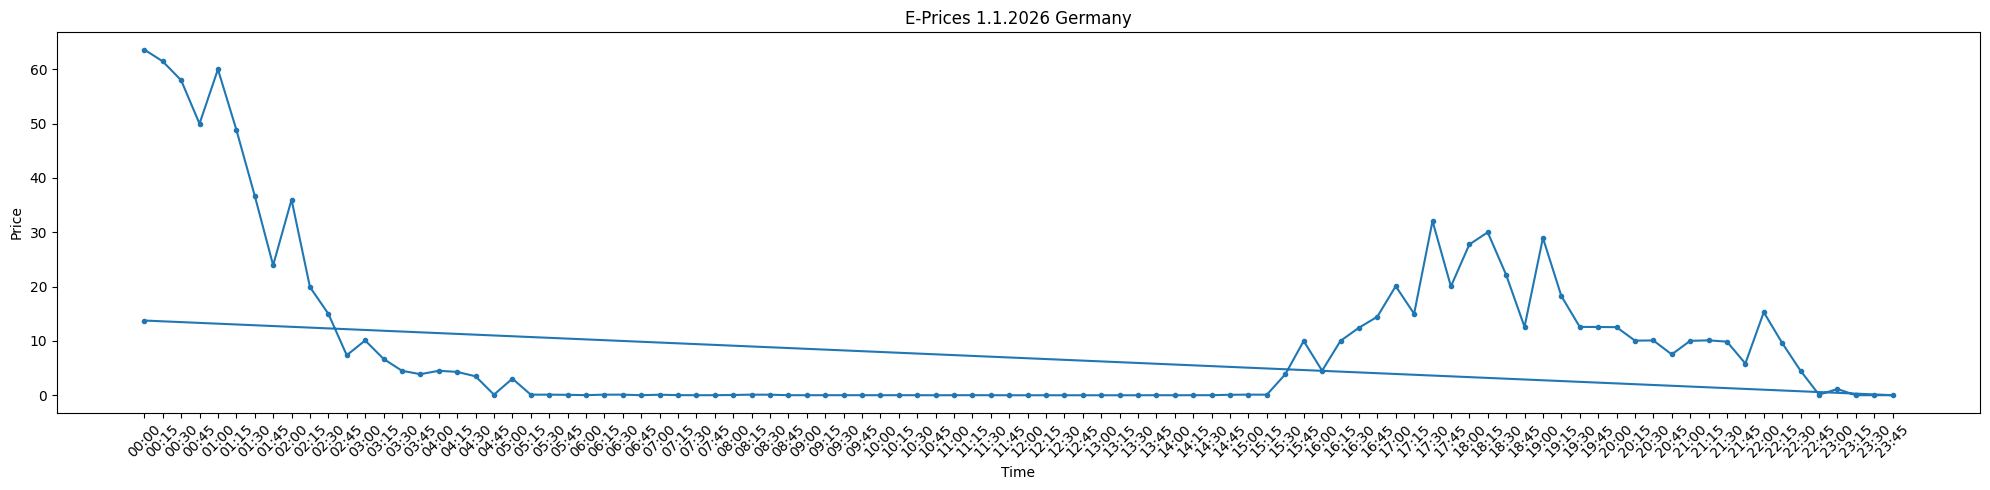

In [13]:
plt.figure(figsize=(20, 5))
plt.plot(df['time'], df['price'], marker='.', linestyle='-')
plt.title('E-Prices 1.1.2026 Germany')
plt.xlabel('Time')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()

Here is a nice visualisation of the prices for that first day. Processing the raw data got more complicated then I thought. We will need to create some custom functions when we call up the API to make our life more easier. The problem was that the API query returned us a one column pandas series, that we needed to turn into a Data Frame and then separe the columns. Last semester's group also pivoted the data for their usage.


### Let's check if we can download the data for period of 6 years

In [14]:
start3 = pd.Timestamp('20200101', tz='Europe/Brussels')    
end3 = pd.Timestamp('20260101', tz='Europe/Brussels')

In [15]:
E_prices_5Y = client.query_day_ahead_prices(country_code, start=start3, end=end3)
E_prices_5Y.head(10)

2020-01-01 00:00:00+01:00    41.88
2020-01-01 01:00:00+01:00    38.60
2020-01-01 02:00:00+01:00    36.55
2020-01-01 03:00:00+01:00    32.32
2020-01-01 04:00:00+01:00    30.85
2020-01-01 05:00:00+01:00    30.14
2020-01-01 06:00:00+01:00    30.17
2020-01-01 07:00:00+01:00    30.00
2020-01-01 08:00:00+01:00    30.65
2020-01-01 09:00:00+01:00    30.65
dtype: float64

In [16]:
E_prices_5Y.tail(10)

2025-12-31 21:45:00+01:00    69.69
2025-12-31 22:00:00+01:00    87.95
2025-12-31 22:15:00+01:00    81.37
2025-12-31 22:30:00+01:00    82.47
2025-12-31 22:45:00+01:00    73.77
2025-12-31 23:00:00+01:00    86.30
2025-12-31 23:15:00+01:00    76.48
2025-12-31 23:30:00+01:00    75.75
2025-12-31 23:45:00+01:00    67.26
2026-01-01 00:00:00+01:00    63.64
dtype: float64

It worked without a problem

### Cross Border Flows Germany-France January 2026

In [17]:
cross_border_flows_jan26 = client.query_crossborder_flows(country_code_from, country_code_to, start=start, end=end)

In [18]:
cross_border_flows_jan26

2026-01-01 00:00:00+01:00     995.4513
2026-01-01 00:15:00+01:00    1013.0796
2026-01-01 00:30:00+01:00    1071.3059
2026-01-01 00:45:00+01:00    1072.0766
2026-01-01 01:00:00+01:00    1409.5855
                               ...    
2026-01-31 22:45:00+01:00       0.0000
2026-01-31 23:00:00+01:00       0.0000
2026-01-31 23:15:00+01:00       0.0000
2026-01-31 23:30:00+01:00       0.0000
2026-01-31 23:45:00+01:00       0.0000
Freq: 15min, Length: 2976, dtype: float64

Now I am also going to test some functions that return a pandas data frame output. They might be easier to work with.

### Pandas Data Frames

In [51]:
load_jan = client.query_load(country_code, start=start, end=end)
load_jan

,Actual Load
2026-01-01 00:00:00+01:00,47282.350740
2026-01-01 00:15:00+01:00,46937.402540
2026-01-01 00:30:00+01:00,47016.188530
2026-01-01 00:45:00+01:00,46823.602440
2026-01-01 01:00:00+01:00,46801.367250
...,...
2026-01-31 22:45:00+01:00,55921.836769
2026-01-31 23:00:00+01:00,55040.235270
2026-01-31 23:15:00+01:00,54342.143489
2026-01-31 23:30:00+01:00,53483.338210


In [54]:
load_jan.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2976 entries, 2026-01-01 00:00:00+01:00 to 2026-01-31 23:45:00+01:00
Freq: 15min
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Actual Load  2976 non-null   float64
dtypes: float64(1)
memory usage: 46.5 KB


In [56]:
df = load_jan
df["date"] = df.index.date                    
df["time"] = df.index.strftime("%H:%M")      
df.head(5)

,Actual Load,date,time
2026-01-01 00:00:00+01:00,47282.35074,2026-01-01,00:00
2026-01-01 00:15:00+01:00,46937.40254,2026-01-01,00:15
2026-01-01 00:30:00+01:00,47016.18853,2026-01-01,00:30
2026-01-01 00:45:00+01:00,46823.60244,2026-01-01,00:45
2026-01-01 01:00:00+01:00,46801.36725,2026-01-01,01:00


The load is probably given in MWs.

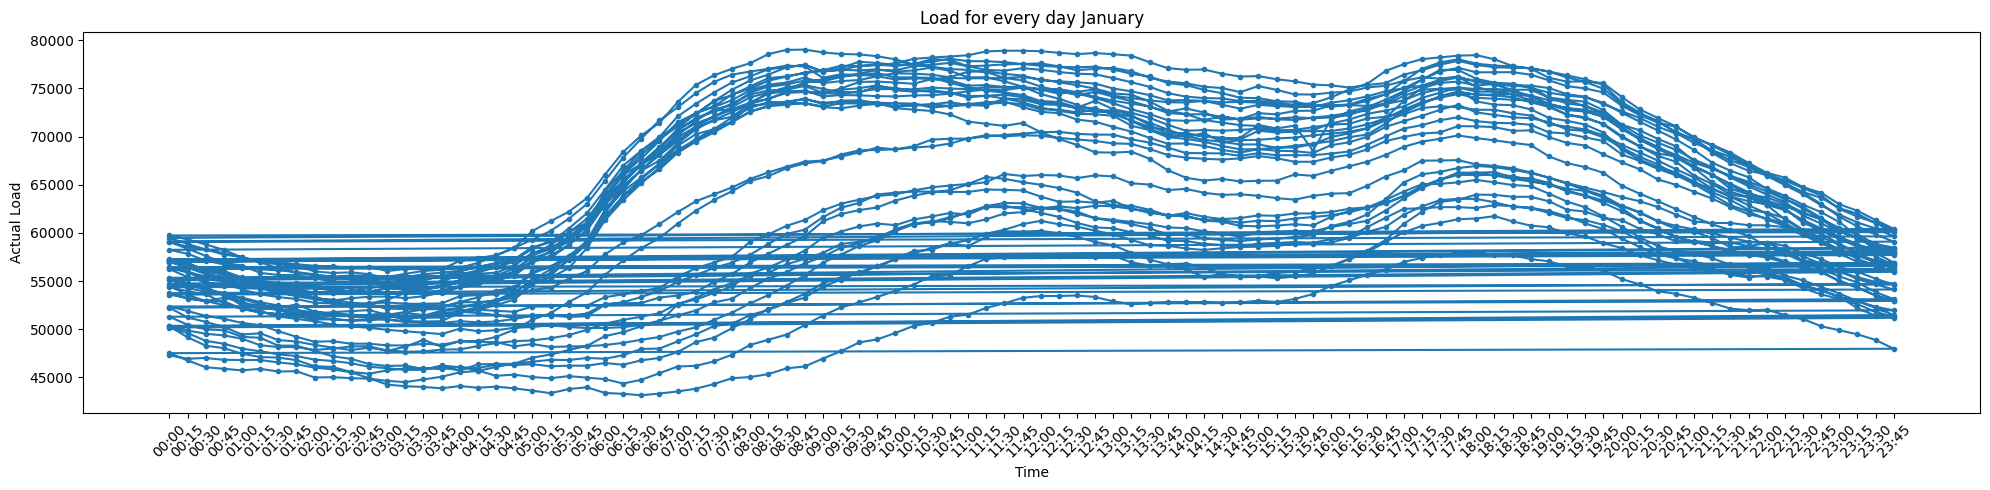

In [60]:
plt.figure(figsize=(20, 5))
plt.plot(df['time'], df['Actual Load'], marker='.', linestyle='-')
plt.title("Load for every day January")
plt.xlabel('Time')
plt.ylabel('Actual Load')
plt.xticks(rotation=45)
plt.tight_layout()

This gives us a pandas series with the date, time (15 min interval) and probobably megawatts of energy

### Other options

Let's check all the other options that return pandas series or pandas data frames:

In [27]:
print("Net Positions:")
client.query_net_position(country_code, start=start, end=end, dayahead=True)

Net Positions:


2026-01-01 00:00:00+01:00    10422.6
2026-01-01 00:15:00+01:00    11149.7
2026-01-01 00:30:00+01:00    11792.6
2026-01-01 00:45:00+01:00    12217.9
2026-01-01 01:00:00+01:00    12894.3
                              ...   
2026-01-31 22:45:00+01:00     4137.4
2026-01-31 23:00:00+01:00     3762.7
2026-01-31 23:15:00+01:00     4082.2
2026-01-31 23:30:00+01:00     4286.1
2026-01-31 23:45:00+01:00     4694.3
Length: 2976, dtype: float64

In [34]:
print("Scheduled Exchanges:")
client.query_scheduled_exchanges(country_code_from, country_code_to, start=start, end=end, dayahead=False)

Scheduled Exchanges:


2026-01-01 00:00:00+01:00       0.00
2026-01-01 00:15:00+01:00    8036.80
2026-01-01 00:30:00+01:00       0.00
2026-01-01 00:45:00+01:00       0.00
2026-01-01 01:00:00+01:00    8166.00
                              ...   
2026-01-31 22:45:00+01:00    2027.03
2026-01-31 23:00:00+01:00    1628.46
2026-01-31 23:15:00+01:00    1328.00
2026-01-31 23:30:00+01:00    1674.30
2026-01-31 23:45:00+01:00     913.30
Freq: 15min, Length: 2976, dtype: float64

In [35]:
print("net transfer capacity dayahead:")
client.query_net_transfer_capacity_dayahead(country_code_from, country_code_to, start=start, end=end)

net transfer capacity dayahead:


NoMatchingDataError: 

In [36]:
print("net transfer capacity monthhead:")
client.query_net_transfer_capacity_monthahead(country_code_from, country_code_to, start=start, end=end)

net transfer capacity monthhead:


2026-01-01 00:00:00+01:00    1200.0
2026-01-02 00:00:00+01:00    1200.0
2026-01-03 00:00:00+01:00    1200.0
2026-01-04 00:00:00+01:00    1200.0
2026-01-05 00:00:00+01:00    1200.0
2026-01-06 00:00:00+01:00    1200.0
2026-01-07 00:00:00+01:00    1200.0
2026-01-08 00:00:00+01:00    1200.0
2026-01-09 00:00:00+01:00    1200.0
2026-01-10 00:00:00+01:00    1200.0
2026-01-11 00:00:00+01:00    1200.0
2026-01-12 00:00:00+01:00    1200.0
2026-01-13 00:00:00+01:00    1200.0
2026-01-14 00:00:00+01:00    1200.0
2026-01-15 00:00:00+01:00    1200.0
2026-01-16 00:00:00+01:00    1200.0
2026-01-17 00:00:00+01:00    1200.0
2026-01-18 00:00:00+01:00    1200.0
2026-01-19 00:00:00+01:00    1200.0
2026-01-20 00:00:00+01:00    1200.0
2026-01-21 00:00:00+01:00    1200.0
2026-01-22 00:00:00+01:00    1200.0
2026-01-23 00:00:00+01:00    1200.0
2026-01-24 00:00:00+01:00    1200.0
2026-01-25 00:00:00+01:00    1200.0
2026-01-26 00:00:00+01:00    1200.0
2026-01-27 00:00:00+01:00    1200.0
2026-01-28 00:00:00+01:00   

In [37]:
print("net transfer capacity weekhead:")
client.query_net_transfer_capacity_weekahead(country_code_from, country_code_to, start=start, end=end)

net transfer capacity weekhead:


2026-01-01 00:00:00+01:00    1200.0
2026-01-02 00:00:00+01:00    1200.0
2026-01-03 00:00:00+01:00    1200.0
2026-01-04 00:00:00+01:00    1200.0
2026-01-05 00:00:00+01:00    1200.0
2026-01-06 00:00:00+01:00    1800.0
2026-01-07 00:00:00+01:00    2500.0
2026-01-08 00:00:00+01:00    1200.0
2026-01-09 00:00:00+01:00    1200.0
2026-01-10 00:00:00+01:00    1200.0
2026-01-11 00:00:00+01:00    1200.0
2026-01-12 00:00:00+01:00    1200.0
2026-01-13 00:00:00+01:00    1200.0
2026-01-14 00:00:00+01:00    1200.0
2026-01-15 00:00:00+01:00    1200.0
2026-01-16 00:00:00+01:00    1200.0
2026-01-17 00:00:00+01:00    1200.0
2026-01-18 00:00:00+01:00    1200.0
2026-01-19 00:00:00+01:00    1200.0
2026-01-20 00:00:00+01:00    1800.0
2026-01-21 00:00:00+01:00    1200.0
2026-01-22 00:00:00+01:00    1200.0
2026-01-23 00:00:00+01:00    1200.0
2026-01-24 00:00:00+01:00    1200.0
2026-01-25 00:00:00+01:00    1200.0
2026-01-26 00:00:00+01:00    1500.0
2026-01-27 00:00:00+01:00    1200.0
2026-01-28 00:00:00+01:00   

In [38]:
print("net transfer capacity yearhead:")
client.query_net_transfer_capacity_yearahead(country_code_from, country_code_to, start=start, end=end)

net transfer capacity yearhead:


2026-01-02 00:00:00+01:00    1200.0
dtype: float64

In [43]:
print("Interday offered capacity:")
client.query_intraday_offered_capacity(country_code_from, country_code_to, start=start2, end=end2, implicit=True)

Interday offered capacity:


2026-01-01 00:00:00+01:00    0.0
2026-01-01 00:00:00+01:00    0.0
2026-01-01 00:15:00+01:00    0.0
2026-01-01 00:15:00+01:00    0.1
2026-01-01 00:30:00+01:00    0.0
                            ... 
2026-01-01 23:30:00+01:00    0.0
2026-01-01 23:30:00+01:00    0.0
2026-01-01 23:45:00+01:00    0.0
2026-01-01 23:45:00+01:00    0.0
2026-01-01 23:45:00+01:00    0.0
Length: 240, dtype: float64

In [45]:
print("Offered capacity:")
client.query_offered_capacity(country_code_from, country_code_to, contract_marketagreement_type, start=start2, end=end2, implicit=True)

Offered capacity:


NoMatchingDataError: 

In [46]:
print("Water and Hydro storage:")
client.query_aggregate_water_reservoirs_and_hydro_storage(country_code, start=start, end=end)

Water and Hydro storage:


NoMatchingDataError: 

In [61]:
client.query_load_forecast(country_code, start=start, end=end)

,Forecasted Load
2026-01-01 00:00:00+01:00,47568.380368
2026-01-01 00:15:00+01:00,46773.529665
2026-01-01 00:30:00+01:00,46632.893699
2026-01-01 00:45:00+01:00,46143.818809
2026-01-01 01:00:00+01:00,45460.909349
...,...
2026-01-31 22:45:00+01:00,54160.835374
2026-01-31 23:00:00+01:00,53713.531609
2026-01-31 23:15:00+01:00,52854.765143
2026-01-31 23:30:00+01:00,52286.840383


In [63]:
client.query_wind_and_solar_forecast(country_code, start=start, end=end, psr_type=None)

,Solar,Wind Offshore,Wind Onshore
2026-01-01 00:00:00+01:00,0.0,5180.17,31753.55560
2026-01-01 00:15:00+01:00,0.0,5216.29,32071.42316
2026-01-01 00:30:00+01:00,0.0,5227.66,32387.13161
2026-01-01 00:45:00+01:00,0.0,5267.57,32699.57258
2026-01-01 01:00:00+01:00,0.0,5311.94,33000.93988
...,...,...,...
2026-01-31 22:45:00+01:00,0.0,6939.51,15752.06944
2026-01-31 23:00:00+01:00,0.0,6926.40,15545.19633
2026-01-31 23:15:00+01:00,0.0,6915.76,15398.11278
2026-01-31 23:30:00+01:00,0.0,6902.10,15251.43960


In [64]:
client.query_import(country_code, start, end)

,AT,BE,CH,CZ,DK_1,DK_2,FR,NO_2,NL,PL,SE_4,sum
2026-01-01 00:00:00+01:00,77.032,0.000000,0.0,0.00,0.00,732.616,0.0000,622.40,0.00,0.0,216.864700,1648.912700
2026-01-01 00:15:00+01:00,76.992,13.193479,0.0,0.32,0.00,828.095,0.0000,68.64,152.72,0.0,216.864685,1356.825164
2026-01-01 00:30:00+01:00,58.792,24.493658,0.0,7.04,0.00,832.073,0.0000,0.00,197.32,0.0,216.859192,1336.577850
2026-01-01 00:45:00+01:00,59.548,22.501012,0.0,22.40,0.00,781.288,0.0000,0.00,230.84,0.0,216.881210,1333.458222
2026-01-01 01:00:00+01:00,104.584,0.000000,0.0,20.48,0.00,720.889,0.0000,0.00,0.00,0.0,216.875702,1062.828702
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-31 22:45:00+01:00,108.112,68.879720,0.0,1042.56,320.64,597.257,735.4199,1262.08,0.00,0.0,216.875717,4351.824337
2026-01-31 23:00:00+01:00,126.028,77.545752,0.0,1059.20,518.40,585.791,738.2268,1363.04,0.00,0.0,216.875717,4685.107269
2026-01-31 23:15:00+01:00,133.196,77.088744,0.0,1038.72,515.52,568.851,839.8206,1072.80,0.00,0.0,216.875717,4462.872061
2026-01-31 23:30:00+01:00,75.376,66.574836,0.0,1128.96,487.04,550.848,695.5844,611.84,0.00,0.0,216.875717,3833.098953


In [66]:
client.query_unavailability_of_offshore_grid(country_code, start, end)

,11TD2L000000346S|TTG/155/BORKUM RIFFGRUND 2-DOLWIN GAMMA/AC155|BORKUM RIFFGRUND 2-DOLWIN GAMMA,11TD2L000000334Z|TTG/600/DOERPEN W-DOLWIN GAMMA/DC604|DOERPEN W-DOLWIN GAMMA,11T0-0000-0061-1|TTG/155/BORKUM RIFFGRUND 2-DOLWIN GAMMA/AC154|BORKUM RIFFGRUND 2-DOLWIN GAMMA,11TD2L000000354T|TTG/155/DOLWIN GAMMA-MERKUR/AC156|DOLWIN GAMMA-MERKUR,11TD2L000000355R|TTG/155/DOLWIN GAMMA-MERKUR/AC157|DOLWIN GAMMA-MERKUR,11TD2L000000289E|TTG/155/DOLWIN BETA-GODE WIND1/AC136|DOLWIN BETA-GODE WIND1,11TD2L000000290T|TTG/155/DOLWIN BETA-GODE WIND1/AC137|DOLWIN BETA-GODE WIND1,11TD2L000000292P|TTG/155/DOLWIN BETA-GODE WIND2/AC139|DOLWIN BETA-GODE WIND2,11TD2L000000309Y|TTG/600/DOERPEN W-DOLWIN BETA/DC603|DOERPEN W-DOLWIN BETA,11TD2L000000291R|TTG/155/DOLWIN BETA-GODE WIND2/AC138|DOLWIN BETA-GODE WIND2,...,11TD2L000000351Z|TTG/155/BORWIN GAMMA-HOHE SEE/AC146|BORWIN GAMMA-HOHE SEE,11TD2L000000361W|TTG/600/BORWIN GAMMA-EMDEN O/DC607|BORWIN GAMMA-EMDEN O,11TD2L000000352X|TTG/155/BORWIN GAMMA-HOHE SEE/AC147|BORWIN GAMMA-HOHE SEE,11TD2L000000353V|TTG/155/BORWIN GAMMA-HOHE SEE/AC148|BORWIN GAMMA-HOHE SEE,11TD2L000000349M|TTG/155/BORWIN GAMMA-GLOBAL TECH 1/AC149|BORWIN GAMMA-GLOBAL TECH 1,11TD2L0000003500|TTG/155/BORWIN GAMMA-GLOBAL TECH 1/AC150|BORWIN GAMMA-GLOBAL TECH 1,11TD2L000000259N|TTG/155/BARD OFFSHORE 1-BORWINALPHA/AC102|BARD OFFSHORE 1-BORWINALPHA,11TD2L0000002601|TTG/155/BARD OFFSHORE 1-BORWINALPHA/AC103|BARD OFFSHORE 1-BORWINALPHA,11T0-0000-1551-B|TTG/600/DOLWIN EPSILON-EMDEN O/DC611|DOLWIN EPSILON-EMDEN O,11T0-0000-1566-T|TTG/600/BORWIN EPSILON-GARREL KONVERTER 1/DC612|BORWIN EPSILON-GARREL KONVERTER 1
2026-01-10 10:24:00+00:00,208.7,770.1,197.26,194.16,192.38,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-10 10:25:00+00:00,208.7,770.1,197.26,194.16,192.38,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-10 10:26:00+00:00,208.7,770.1,197.26,194.16,192.38,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-10 10:27:00+00:00,208.7,770.1,197.26,194.16,192.38,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-10 10:28:00+00:00,208.7,770.1,197.26,194.16,192.38,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29 11:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.0
2026-01-29 11:11:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.0
2026-01-29 11:12:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.0
2026-01-29 11:13:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.0


### Conclusion:
Some of the API calls are straight forward to use, while others require additional inputs. It is also visible that not every query return an output at our time of testing.